# Week 2 / Day 3 — Daily Challenge
## Analyse des accidents d’avion et des décès

Dans ce challenge, nous analysons le dataset « Airplane Crashes and Fatalities up to 2023 ». L’objectif est d’utiliser Python, Pandas, NumPy, SciPy, Matplotlib et Seaborn pour nettoyer les données, explorer les tendances, réaliser des analyses statistiques et produire des visualisations pertinentes.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv to Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv


In [7]:
import os
import pandas as pd
os.listdir()
import pandas as pd
import os

os.listdir()

df = pd.read_csv(
    "/content/Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv",
    encoding="latin1"
)

df.head()
df.head()
df.shape
df.columns
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   4998 non-null   object 
 1   Time                   3486 non-null   object 
 2   Location               4994 non-null   object 
 3   Operator               4988 non-null   object 
 4   Flight #               1329 non-null   object 
 5   Route                  4221 non-null   object 
 6   AC Type                4983 non-null   object 
 7   Registration           4724 non-null   object 
 8   cn/ln                  4330 non-null   object 
 9   Aboard                 4980 non-null   float64
 10  Aboard Passangers      4769 non-null   float64
 11  Aboard Crew            4772 non-null   float64
 12  Fatalities             4990 non-null   float64
 13  Fatalities Passangers  4756 non-null   float64
 14  Fatalities Crew        4757 non-null   float64
 15  Grou

,0
Date,0
Time,1512
Location,4
Operator,10
Flight #,3669
Route,777
AC Type,15
Registration,274
cn/ln,668
Aboard,18


convertir l date

In [8]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["Year"] = df["Date"].dt.year
df["Decade"] = (df["Year"] // 10) * 10

In [9]:
numeric_columns = ["Aboard", "Fatalities", "Ground"]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

Valeurs manquantes avant nettoyage :


,0
Date,0
Time,1512
Location,4
Operator,10
Flight #,3669
Route,777
AC Type,15
Registration,274
cn/ln,668
Aboard,18


Dimensions du dataset après nettoyage :
(4975, 21)
Statistiques descriptives du taux de survie :


,Survival_Rate
count,4975.000000
mean,0.181489
std,0.311724
min,0.000000
25%,0.000000
50%,0.000000
75%,0.250000
max,1.000000


Taux moyen de survie : 0.181489019431307
Taux médian de survie : 0.0


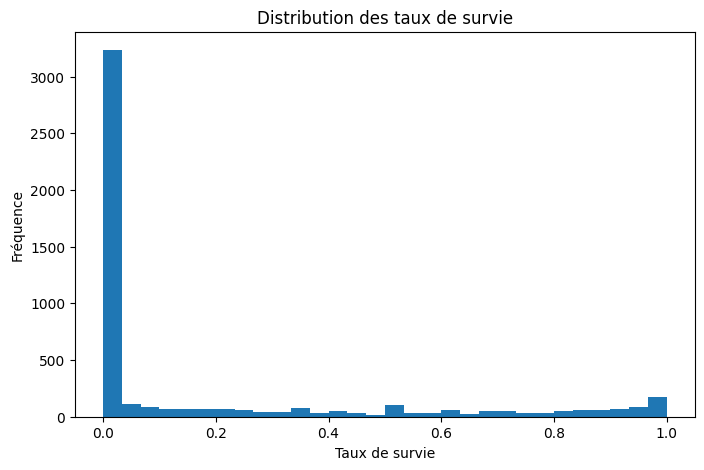

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Vérifier les valeurs manquantes dans le dataset original
print("Valeurs manquantes avant nettoyage :")
display(df.isnull().sum())

# 2. Créer la colonne Survivors
# Survivors = nombre de personnes à bord - nombre de décès
if "Aboard" in df.columns and "Fatalities" in df.columns:
    df["Survivors"] = df["Aboard"] - df["Fatalities"]

# 3. Créer la colonne Survival_Rate
# Survival_Rate = Survivors / Aboard
df["Survival_Rate"] = np.where(
    df["Aboard"] > 0,
    df["Survivors"] / df["Aboard"],
    np.nan
)

# 4. Nettoyer les lignes importantes pour l'analyse
# On garde seulement les lignes où les colonnes essentielles sont disponibles
df_clean = df.dropna(
    subset=["Date", "Year", "Fatalities", "Aboard", "Survival_Rate"]
)

# 5. Afficher la taille du dataset après nettoyage
print("Dimensions du dataset après nettoyage :")
print(df_clean.shape)

# 6. Statistiques descriptives du taux de survie
print("Statistiques descriptives du taux de survie :")
display(df_clean["Survival_Rate"].describe())

# 7. Calculer le taux moyen et médian de survie
mean_survival_rate = df_clean["Survival_Rate"].mean()
median_survival_rate = df_clean["Survival_Rate"].median()

print("Taux moyen de survie :", mean_survival_rate)
print("Taux médian de survie :", median_survival_rate)

# 8. Histogramme du taux de survie
plt.figure(figsize=(8, 5))
plt.hist(df_clean["Survival_Rate"].dropna(), bins=30)
plt.title("Distribution des taux de survie")
plt.xlabel("Taux de survie")
plt.ylabel("Fréquence")
plt.show()

## Analyse du taux de survie

Dans cette partie, nous avons créé deux nouvelles colonnes : `Survivors` et `Survival_Rate`.

La colonne `Survivors` représente le nombre de personnes ayant survécu à chaque accident. Elle est calculée en soustrayant le nombre de décès (`Fatalities`) du nombre de personnes à bord (`Aboard`).

La colonne `Survival_Rate` représente le taux de survie pour chaque accident. Elle est calculée en divisant le nombre de survivants par le nombre total de personnes à bord.

Après la création de ces colonnes, nous avons nettoyé les lignes contenant des valeurs manquantes sur les colonnes essentielles à l’analyse. Ensuite, nous avons calculé les statistiques descriptives du taux de survie, ainsi que le taux moyen et le taux médian de survie.

In [11]:
total_accidents = df_clean.shape[0]
print("Nombre total d'accidents :", total_accidents)

Nombre total d'accidents : 4975


In [12]:
total_fatalities = df_clean["Fatalities"].sum()
print("Nombre total de décès :", total_fatalities)

Nombre total de décès : 111561.0


In [13]:
df_clean["Fatalities"].describe()

,Fatalities
count,4975.000000
mean,22.424322
std,35.100056
min,0.000000
25%,4.000000
50%,11.000000
75%,25.000000
max,583.000000


In [14]:
accidents_by_year = df_clean.groupby("Year").size()

accidents_by_year.head()

,0
Year,
1908,1
1909,1
1912,1
1913,3
1915,2


In [15]:
fatalities = df_clean["Fatalities"].dropna()

mean_fatalities = np.mean(fatalities)
median_fatalities = np.median(fatalities)
std_fatalities = np.std(fatalities)

print("Moyenne des décès :", mean_fatalities)
print("Médiane des décès :", median_fatalities)
print("Écart type des décès :", std_fatalities)

Moyenne des décès : 22.424321608040202
Médiane des décès : 11.0
Écart type des décès : 35.096528073746


In [17]:
from scipy import stats

before_1980 = df_clean[df_clean["Year"] < 1980]["Fatalities"].dropna()
after_1980 = df_clean[df_clean["Year"] >= 1980]["Fatalities"].dropna()

t_stat, p_value = stats.ttest_ind(before_1980, after_1980, equal_var=False)

print("Statistique t :", t_stat)
print("p-value :", p_value)

if p_value < 0.05:
    print("Il existe une différence statistiquement significative entre les deux périodes.")
else:
    print("Il n'existe pas de différence statistiquement significative entre les deux périodes.")

Statistique t : -5.726210885869325
p-value : 1.1305901092936606e-08
Il existe une différence statistiquement significative entre les deux périodes.


Le test t permet de comparer la moyenne des décès entre deux périodes. Si la p-value est inférieure à 0,05, on considère que la différence entre les deux périodes est statistiquement significative.

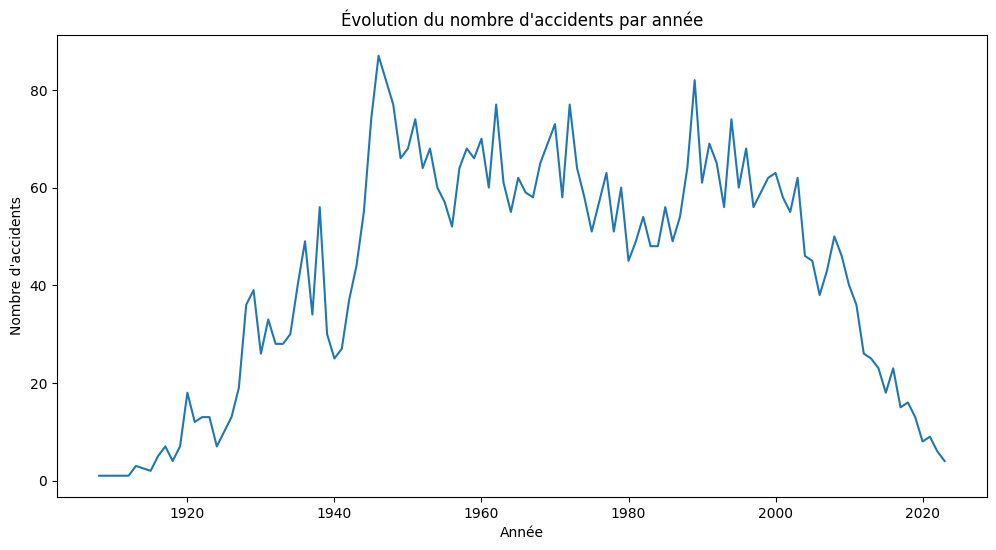

In [19]:
plt.figure(figsize=(12, 6))
accidents_by_year.plot()
plt.title("Évolution du nombre d'accidents par année")
plt.xlabel("Année")
plt.ylabel("Nombre d'accidents")
plt.show()

In [20]:
fatalities_by_year = df_clean.groupby("Year")["Fatalities"].sum()

fatalities_by_year.head()

,Fatalities
Year,
1908,1.0
1909,1.0
1912,5.0
1913,45.0
1915,40.0


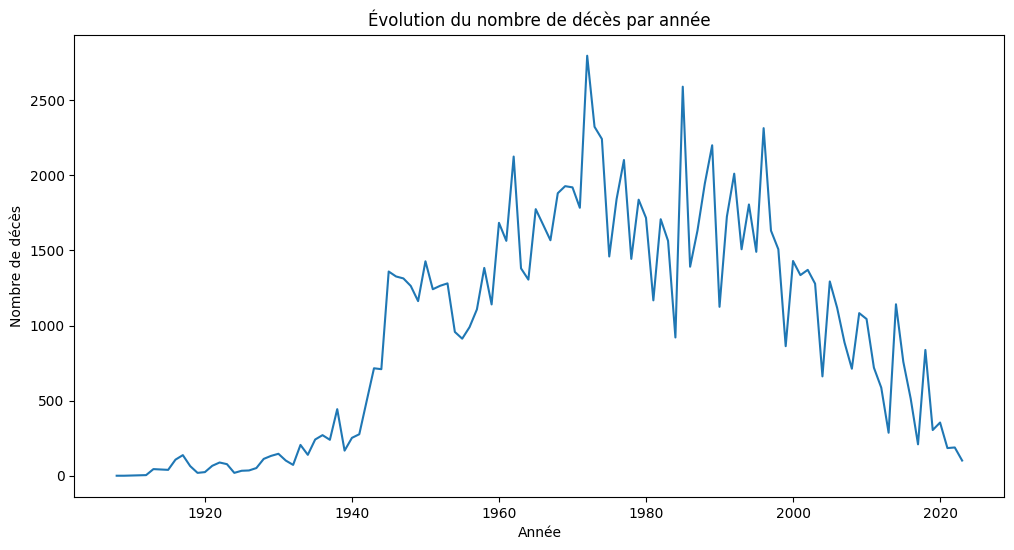

In [21]:
plt.figure(figsize=(12, 6))
fatalities_by_year.plot()
plt.title("Évolution du nombre de décès par année")
plt.xlabel("Année")
plt.ylabel("Nombre de décès")
plt.show()

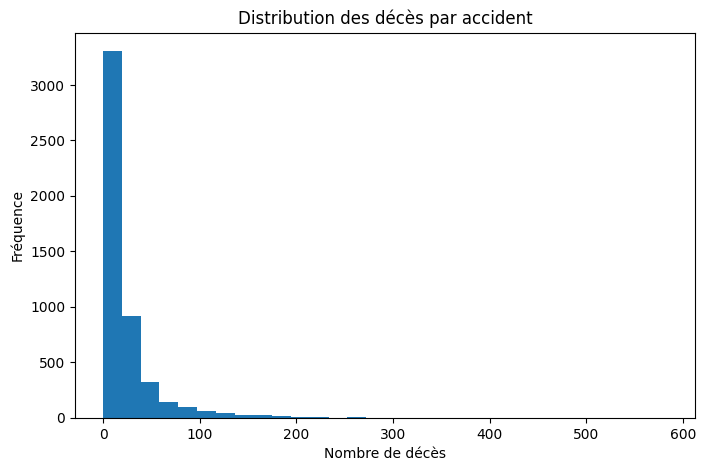

In [22]:
plt.figure(figsize=(8, 5))
plt.hist(df_clean["Fatalities"].dropna(), bins=30)
plt.title("Distribution des décès par accident")
plt.xlabel("Nombre de décès")
plt.ylabel("Fréquence")
plt.show()

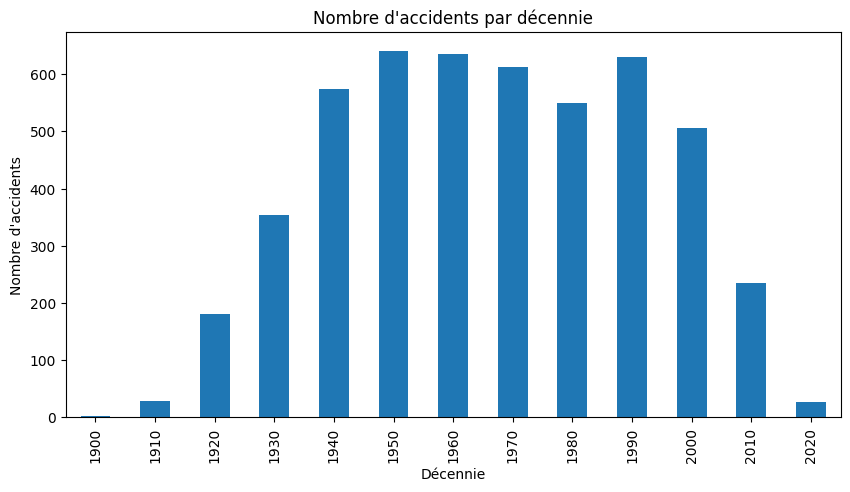

In [23]:
accidents_by_decade = df_clean.groupby("Decade").size()

plt.figure(figsize=(10, 5))
accidents_by_decade.plot(kind="bar")
plt.title("Nombre d'accidents par décennie")
plt.xlabel("Décennie")
plt.ylabel("Nombre d'accidents")
plt.show()

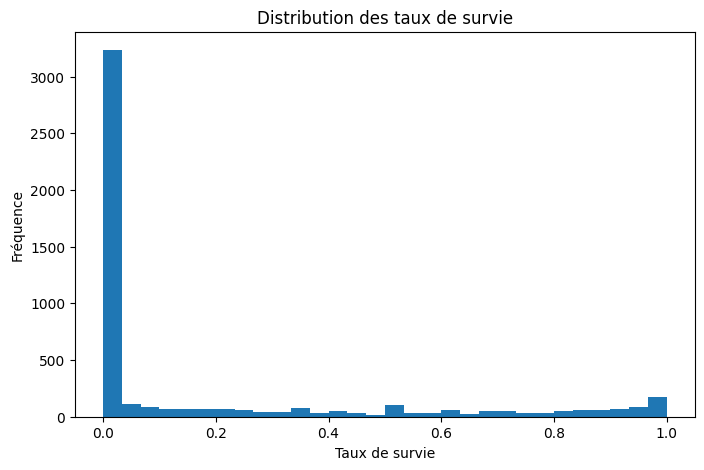

In [24]:
plt.figure(figsize=(8, 5))
plt.hist(df_clean["Survival_Rate"].dropna(), bins=30)
plt.title("Distribution des taux de survie")
plt.xlabel("Taux de survie")
plt.ylabel("Fréquence")
plt.show()

## Rapport d’analyse

Dans cette analyse, nous avons étudié le dataset des accidents d’avion et des décès jusqu’en 2023. Après l’importation des données avec Pandas, nous avons converti la colonne des dates au bon format et créé de nouvelles variables comme l’année et la décennie.

L’analyse exploratoire a permis d’observer le nombre total d’accidents, le nombre total de décès et l’évolution des incidents dans le temps. Les visualisations ont permis de repérer les tendances par année et par décennie.

Avec SciPy, nous avons calculé des statistiques descriptives sur les décès et réalisé un test d’hypothèse pour comparer deux périodes. La p-value du test permet de déterminer si la différence observée entre les périodes est statistiquement significative.

Pandas a été utilisé pour charger, nettoyer et regrouper les données. NumPy a permis de réaliser certains calculs numériques, tandis que SciPy a été utilisé pour l’analyse statistique. Matplotlib et Seaborn ont permis de visualiser les tendances et distributions.